## LOAD LIBRARY

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


## DATA WRANGLING

In [2]:
jobs_df = pd.read_csv("dataset/jobs.csv")
skills_df = pd.read_csv("dataset/skills.csv")
resume_df = pd.read_csv("dataset/resume.csv")

In [3]:
jobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Job Title              324 non-null    object
 1   Category               324 non-null    object
 2   Education Requirement  324 non-null    object
 3   Experience Years       324 non-null    int64 
 4   Required Skills        324 non-null    object
 5   Salary Range           324 non-null    object
dtypes: int64(1), object(5)
memory usage: 15.3+ KB


In [4]:
skills_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Skill Name  120 non-null    object
 1   Category    120 non-null    object
dtypes: object(2)
memory usage: 2.0+ KB


In [5]:
resume_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Resume ID         10000 non-null  object
 1   Resume Text       10000 non-null  object
 2   Education         10000 non-null  object
 3   Experience Years  10000 non-null  int64 
 4   Skills            10000 non-null  object
 5   Job Role          10000 non-null  object
 6   Category          10000 non-null  object
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


In [6]:
# Normalize semua text (spasi, huruf kapital/kecil)
jobs_df = jobs_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
skills_df = skills_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
resume_df = resume_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)

C:\Users\hp\AppData\Local\Temp\ipykernel_1940\1157588541.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  jobs_df = jobs_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
C:\Users\hp\AppData\Local\Temp\ipykernel_1940\1157588541.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  skills_df = skills_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
C:\Users\hp\AppData\Local\Temp\ipykernel_1940\1157588541.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  resume_df = resume_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [7]:
# Merapikan nama kolom
jobs_df.columns = jobs_df.columns.str.lower().str.replace(" ", "_")
skills_df.columns = skills_df.columns.str.lower().str.replace(" ", "_")
resume_df.columns = resume_df.columns.str.lower().str.replace(" ", "_")

In [8]:
# Cleaning skills (dari resume.csv)
def clean_skills(text):
    text = text.replace("[","").replace("]","").replace("'","")
    skills = text.split(",")
    return [s.strip() for s in skills if s.strip() != ""]

resume_df['skills'] = resume_df['skills'].apply(clean_skills)

In [9]:
# Cleaning skills (dari jobs.csv)
jobs_df['required_skills'] = jobs_df['required_skills'].apply(clean_skills)

In [10]:
# Samakan nama kolom untuk job di jobs.csv dan resume.csv
jobs_df['job_title'] = jobs_df['job_title'].str.strip()
resume_df['job_role'] = resume_df['job_role'].str.strip()

In [11]:
# Cek udah cocok belum (kalau kosong -> job sudah match)
set(resume_df['job_role']) - set(jobs_df['job_title'])

set()

In [12]:
# Normalisasi singkatan jurusan
import re
def clean_education_v2(text):
    text = text.lower()
    
    mapping = {
        "it": "information technology",
        "rn": "nursing",
        "mba": "business administration",
        "mpa": "public administration",
        "hr": "human resources",
        "cpa": "accounting",
        "qa": "quality assurance",
        "ai": "artificial intelligence",
        "pt": "physical therapy"
    }
    
    for k, v in mapping.items():
        text = re.sub(rf'\b{k}\b', v, text)
    
    return text.strip()

resume_df['education_clean_v2'] = resume_df['education'].apply(clean_education_v2)
jobs_df['education_clean_v2'] = jobs_df['education_requirement'].apply(clean_education_v2)

In [13]:
# Drop kolom lama education dan ganti dengan yang baru
resume_df = resume_df.drop(columns=['education'])
resume_df = resume_df.rename(columns={'education_clean_v2': 'education'})

jobs_df = jobs_df.drop(columns=['education_requirement'])
jobs_df = jobs_df.rename(columns={'education_clean_v2': 'education_requirement'})

In [14]:
# Cek apakah sudah terganti
resume_df.head(10)

,resume_id,resume_text,experience_years,skills,job_role,category,education
0,r000000,education: bachelor's in computer science expe...,2,[market research|maven|java|rest api|spring bo...,java backend developer,technology,bachelor's in computer science
1,r000001,education: master's in microbiology experience...,3,[agile|data analysis|precision|problem solving...,microbiologist,science & research,master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,2,[react|customer service|technical knowledge|pl...,plumber,skilled trades,apprenticeship
3,r000003,education: bachelor's in computer science expe...,0,[mysql|query optimization|symfony|terraform|ph...,php developer,technology,bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,3,[problem solving|docker|creativity|scrum|ansib...,art director,creative & design,bachelor's in design
5,r000005,education: administrative certification experi...,2,[ci/cd|problem solving|database design|pytorch...,executive assistant,administration,administrative certification
6,r000006,education: bachelor's in computer science expe...,3,[distributed systems|cql|cassandra|performance...,cassandra developer,technology,bachelor's in computer science
7,r000007,education: bachelor's in it experience: 1 year...,1,[performance tuning|sql|etl|data integration|j...,informatica developer,data & analytics,bachelor's in information technology
8,r000008,education: pt license experience: 4 years skil...,4,[communication|swift|anatomy knowledge|exercis...,physical therapist,healthcare,physical therapy license
9,r000009,education: bachelor's in computer science expe...,5,[postgresql|distributed systems|kanban|phoenix...,elixir developer,technology,bachelor's in computer science


In [15]:
jobs_df.head(10)

,job_title,category,experience_years,required_skills,salary_range,education_requirement
0,software engineer,technology,2,[python|java|c++|git|software design|problem s...,80-150k,bachelor's in computer science|bachelor's in e...
1,full stack developer,technology,2,[javascript|react|node.js|html/css|database|git],75-140k,diploma in information technology|bachelor's i...
2,frontend developer,technology,1,[javascript|react|vue.js|css|html|ui/ux design],70-130k,diploma in information technology|bachelor's i...
3,backend developer,technology,2,[python|java|node.js|database design|api devel...,75-135k,bachelor's in computer science
4,devops engineer,technology,3,[docker|kubernetes|aws|linux|ci/cd|scripting],85-150k,bachelor's in computer science|information tec...
5,cloud architect,technology,5,[aws|azure|gcp|system design|networking|security],120-200k,bachelor's in computer science|cloud certifica...
6,data scientist,technology,2,[python|machine learning|statistics|tensorflow...,90-160k,master's in data science|bachelor's in mathema...
7,machine learning engineer,technology,3,[python|tensorflow|pytorch|deep learning|stati...,100-180k,master's in computer science|master's in artif...
8,data engineer,technology,2,[python|spark|hadoop|sql|data warehousing|etl],85-155k,bachelor's in computer science
9,database administrator,technology,2,[sql|mongodb|database optimization|linux|backu...,70-130k,bachelor's in information technology|informati...


In [16]:
print(jobs_df['required_skills'].iloc[0])
print(type(jobs_df['required_skills'].iloc[0]))

['python|java|c++|git|software design|problem solving']
<class 'list'>


In [17]:
# Cleaning skills
def clean_skills(text):
    import pandas as pd
    
    if pd.isna(text):
        return []
    
    # kalau list
    if isinstance(text, list):
        # kalau list cuma 1 elemen → ambil isinya
        if len(text) == 1:
            text = text[0]
        else:
            return [str(s).strip().lower() for s in text]
    
    # sekarang pasti string
    text = str(text).lower()
    
    text = text.replace("[","").replace("]","")
    text = text.replace("|", ",")
    
    skills = text.split(",")
    
    return [s.strip() for s in skills if s.strip() != ""]

In [18]:
jobs_df['required_skills'] = jobs_df['required_skills'].apply(clean_skills)
resume_df['skills'] = resume_df['skills'].apply(clean_skills)

In [19]:
# Cek apakah sudah berubah jadi list di bagian required skills & skills
jobs_df.head()

,job_title,category,experience_years,required_skills,salary_range,education_requirement
0,software engineer,technology,2,"[python, java, c++, git, software design, prob...",80-150k,bachelor's in computer science|bachelor's in e...
1,full stack developer,technology,2,"[javascript, react, node.js, html/css, databas...",75-140k,diploma in information technology|bachelor's i...
2,frontend developer,technology,1,"[javascript, react, vue.js, css, html, ui/ux d...",70-130k,diploma in information technology|bachelor's i...
3,backend developer,technology,2,"[python, java, node.js, database design, api d...",75-135k,bachelor's in computer science
4,devops engineer,technology,3,"[docker, kubernetes, aws, linux, ci/cd, script...",85-150k,bachelor's in computer science|information tec...


In [20]:
resume_df.head()

,resume_id,resume_text,experience_years,skills,job_role,category,education
0,r000000,education: bachelor's in computer science expe...,2,"[market research, maven, java, rest api, sprin...",java backend developer,technology,bachelor's in computer science
1,r000001,education: master's in microbiology experience...,3,"[agile, data analysis, precision, problem solv...",microbiologist,science & research,master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,2,"[react, customer service, technical knowledge,...",plumber,skilled trades,apprenticeship
3,r000003,education: bachelor's in computer science expe...,0,"[mysql, query optimization, symfony, terraform...",php developer,technology,bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,3,"[problem solving, docker, creativity, scrum, a...",art director,creative & design,bachelor's in design


In [21]:
# Hapus kolom tidak perlu
jobs_df.drop(columns=['experience_years', 'salary_range'], inplace=True)
resume_df.drop(columns=['experience_years', 'resume_id'], inplace=True)

In [22]:
# Cek lagi tabel final
jobs_df.head()

,job_title,category,required_skills,education_requirement
0,software engineer,technology,"[python, java, c++, git, software design, prob...",bachelor's in computer science|bachelor's in e...
1,full stack developer,technology,"[javascript, react, node.js, html/css, databas...",diploma in information technology|bachelor's i...
2,frontend developer,technology,"[javascript, react, vue.js, css, html, ui/ux d...",diploma in information technology|bachelor's i...
3,backend developer,technology,"[python, java, node.js, database design, api d...",bachelor's in computer science
4,devops engineer,technology,"[docker, kubernetes, aws, linux, ci/cd, script...",bachelor's in computer science|information tec...


In [23]:
resume_df.head()

,resume_text,skills,job_role,category,education
0,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,technology,bachelor's in computer science
1,education: master's in microbiology experience...,"[agile, data analysis, precision, problem solv...",microbiologist,science & research,master's in microbiology
2,education: apprenticeship experience: 2 years ...,"[react, customer service, technical knowledge,...",plumber,skilled trades,apprenticeship
3,education: bachelor's in computer science expe...,"[mysql, query optimization, symfony, terraform...",php developer,technology,bachelor's in computer science
4,education: bachelor's in design experience: 3 ...,"[problem solving, docker, creativity, scrum, a...",art director,creative & design,bachelor's in design


In [24]:
# Sebelum dimerge, pastikan nama kolom sama
jobs_df['job_title'] = jobs_df['job_title'].str.strip().str.lower()
resume_df['job_role'] = resume_df['job_role'].str.strip().str.lower()

In [25]:
# Cek apakah sudah match apa belum (kosong berarti match)
set(resume_df['job_role']) - set(jobs_df['job_title'])

set()

In [26]:
# Merge tabel
merged_df = resume_df.merge(
    jobs_df,
    left_on='job_role',
    right_on='job_title',
    how='inner'
)

In [27]:
merged_df.head()

,resume_text,skills,job_role,category_x,education,job_title,category_y,required_skills,education_requirement
0,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,technology,bachelor's in computer science,java backend developer,technology,"[java, spring boot, sql, rest api, microservic...",bachelor's in computer science
1,education: master's in microbiology experience...,"[agile, data analysis, precision, problem solv...",microbiologist,science & research,master's in microbiology,microbiologist,science & research,"[microbiology, laboratory work, research, data...",master's in microbiology
2,education: apprenticeship experience: 2 years ...,"[react, customer service, technical knowledge,...",plumber,skilled trades,apprenticeship,plumber,skilled trades,"[plumbing systems, safety, problem solving, te...",trade school|apprenticeship
3,education: bachelor's in computer science expe...,"[mysql, query optimization, symfony, terraform...",php developer,technology,bachelor's in computer science,php developer,technology,"[php, laravel, symfony, mysql, api development...",bachelor's in computer science
4,education: bachelor's in design experience: 3 ...,"[problem solving, docker, creativity, scrum, a...",art director,creative & design,bachelor's in design,art director,creative & design,"[artistic direction, visual communication, tea...",bachelor's in art|bachelor's in design


In [28]:
len(merged_df)

10000

In [29]:
# Pakai kolom category dari 1 dataset saja (supaya tidak jadi x dan y)
merged_df = merged_df.drop(columns=['category_x'])
merged_df = merged_df.rename(columns={'category_y': 'category'})

In [30]:
# Pakai kolom job role saja untuk jadi label (job_title dihapus)
merged_df = merged_df.drop(columns=['job_title'])

In [31]:
# Cek tabel final
merged_df.head()

,resume_text,skills,job_role,education,category,required_skills,education_requirement
0,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,bachelor's in computer science,technology,"[java, spring boot, sql, rest api, microservic...",bachelor's in computer science
1,education: master's in microbiology experience...,"[agile, data analysis, precision, problem solv...",microbiologist,master's in microbiology,science & research,"[microbiology, laboratory work, research, data...",master's in microbiology
2,education: apprenticeship experience: 2 years ...,"[react, customer service, technical knowledge,...",plumber,apprenticeship,skilled trades,"[plumbing systems, safety, problem solving, te...",trade school|apprenticeship
3,education: bachelor's in computer science expe...,"[mysql, query optimization, symfony, terraform...",php developer,bachelor's in computer science,technology,"[php, laravel, symfony, mysql, api development...",bachelor's in computer science
4,education: bachelor's in design experience: 3 ...,"[problem solving, docker, creativity, scrum, a...",art director,bachelor's in design,creative & design,"[artistic direction, visual communication, tea...",bachelor's in art|bachelor's in design


In [32]:
merged_df.isnull().sum()

resume_text              0
skills                   0
job_role                 0
education                0
category                 0
required_skills          0
education_requirement    0
dtype: int64

In [33]:
# Menghitung jumlah baris duplikat pada dataframe,
# termasuk kolom yang berisi list, dengan cara mengubah list menjadi tuple
duplicated_count = merged_df.apply(
    lambda row: tuple(
        tuple(v) if isinstance(v, list) else v
        for v in row
    ),
    axis=1
).duplicated().sum()

duplicated_count

np.int64(0)

## FEATURE ENGINEERING

### Pisahkan soft skill & hard skill

In [34]:
# List Keyword soft skills

soft_skill_keywords = [
    "creativity", "problem solving", "leadership",
    "project management", "time management",
    "communication", "team work", "teamwork",
    "critical thinking", "empathy", "negotiation",
    "strategic planning", "decision making",
    "budget control", "target setting",
    "attention to detail", "public speaking",
    "quick thinking", "strategic thinking",
    "motivation", "adaptability", "friendliness"
]

# Normalisasi "team work" -> "teamwork"

merged_df['skills'] = merged_df['skills'].apply(
    lambda skills: [
        skill.replace("team work", "teamwork")
        for skill in skills
    ]
)

merged_df['required_skills'] = merged_df['required_skills'].apply(
    lambda skills: [
        skill.replace("team work", "teamwork")
        for skill in skills
    ]
)

# Membuat soft_skills_user

merged_df['soft_skills_user'] = merged_df['skills'].apply(

    lambda skills: [

        skill
        for skill in skills

        if any(
            keyword.lower() in skill.lower()
            for keyword in soft_skill_keywords
        )
    ]
)

# Membuat required_soft_skills

merged_df['required_soft_skills'] = merged_df['required_skills'].apply(

    lambda skills: [

        skill
        for skill in skills

        if any(
            keyword.lower() in skill.lower()
            for keyword in soft_skill_keywords
        )
    ]
)

# MEMBUAT hard_skills_user

merged_df['hard_skills_user'] = merged_df['skills'].apply(

    lambda skills: [

        skill
        for skill in skills

        if not any(
            keyword.lower() in skill.lower()
            for keyword in soft_skill_keywords
        )
    ]
)

# Membuat required_hard_skills_user

merged_df['required_hard_skills_user'] = merged_df['required_skills'].apply(

    lambda skills: [

        skill
        for skill in skills

        if not any(
            keyword.lower() in skill.lower()
            for keyword in soft_skill_keywords
        )
    ]
)

# Hapus kolom lama

merged_df.drop(
    columns=['skills', 'required_skills'],
    inplace=True
)

# Cek hasil
merged_df.head()

,resume_text,job_role,education,category,education_requirement,soft_skills_user,required_soft_skills,hard_skills_user,required_hard_skills_user
0,education: bachelor's in computer science expe...,java backend developer,bachelor's in computer science,technology,bachelor's in computer science,[],[],"[market research, maven, java, rest api, sprin...","[java, spring boot, sql, rest api, microservic..."
1,education: master's in microbiology experience...,microbiologist,master's in microbiology,science & research,master's in microbiology,[problem solving],[problem solving],"[agile, data analysis, precision, scala, resea...","[microbiology, laboratory work, research, data..."
2,education: apprenticeship experience: 2 years ...,plumber,apprenticeship,skilled trades,trade school|apprenticeship,"[problem solving, creativity]",[problem solving],"[react, customer service, technical knowledge,...","[plumbing systems, safety, technical knowledge..."
3,education: bachelor's in computer science expe...,php developer,bachelor's in computer science,technology,bachelor's in computer science,[],[],"[mysql, query optimization, symfony, terraform...","[php, laravel, symfony, mysql, api development..."
4,education: bachelor's in design experience: 3 ...,art director,bachelor's in design,creative & design,bachelor's in art|bachelor's in design,"[problem solving, creativity, communication, t...","[visual communication, team leadership, commun...","[docker, scrum, ansible, design principles, ar...","[artistic direction, design principles]"


### Kategori pekerjaan dipersempit menjadi 5 bidang

In [35]:
# ======================================
# CEK UNIQUE CATEGORY
# ======================================

unique_categories = sorted(
    merged_df['category'].unique()
)

print("=== UNIQUE CATEGORY ===\n")

for i, category in enumerate(unique_categories, 1):
    print(f"{i}. {category}")

# ======================================
# JUMLAH CATEGORY UNIK
# ======================================

print("\nJumlah category unik:", len(unique_categories))

# ======================================
# JUMLAH DATA PER CATEGORY
# ======================================

print("\n=== JUMLAH DATA PER CATEGORY ===\n")

print(
    merged_df['category'].value_counts()
)

=== UNIQUE CATEGORY ===

1. administration
2. agriculture
3. agriculture & food
4. arts & culture
5. beauty & wellness
6. conservation
7. construction & real estate
8. consulting
9. creative & design
10. data & analytics
11. education & training
12. energy & utilities
13. engineering & manufacturing
14. entertainment & media
15. environmental
16. finance & accounting
17. government & public service
18. healthcare
19. hospitality & food service
20. hospitality & tourism
21. human resources
22. human services & social work
23. information services
24. law enforcement
25. legal services
26. marketing & sales
27. media & entertainment
28. media production
29. non-profit & charity
30. operations & supply chain
31. private sector management
32. research & development
33. retail & hospitality
34. sales & customer service
35. science & research
36. skilled trades
37. sports & athletics
38. sports & recreation
39. technology
40. transportation
41. transportation & logistics
42. veterinary

Juml

In [36]:
# ======================================
# CATEGORY MAPPING
# ======================================

category_mapping = {

    # ==================================
    # TECHNOLOGY
    # ==================================

    'technology': 'technology',
    'data & analytics': 'technology',

    # ==================================
    # ECONOMY
    # ==================================

    'finance & accounting': 'economy',
    'marketing & sales': 'economy',
    'private sector management': 'economy',

    # ==================================
    # LAW & PUBLIC SERVICES
    # ==================================

    'government & public service': 'law_and_public_services',
    'law enforcement': 'law_and_public_services',
    'legal services': 'law_and_public_services',

    # ==================================
    # ENGINEERING
    # ==================================

    'energy & utilities': 'engineering',
    'engineering & manufacturing': 'engineering',

    # ==================================
    # CREATIVE DESIGN
    # ==================================

    'arts & culture': 'creative_design',
    'creative & design': 'creative_design',
    'media & entertainment': 'creative_design',
    'media production': 'creative_design'
}

# ======================================
# FILTER CATEGORY YANG ADA DI MAPPING
# ======================================

merged_df = merged_df[
    merged_df['category'].isin(category_mapping.keys())
].copy()

# ======================================
# AMBIL RANDOM 250 DATA
# DARI "data & analytics"
# ======================================

data_analytics_sample = merged_df[
    merged_df['category'] == 'data & analytics'
].sample(
    n=250,
    random_state=42
)

# ======================================
# HAPUS SEMUA data & analytics LAMA
# ======================================

merged_df = merged_df[
    merged_df['category'] != 'data & analytics'
]

# ======================================
# TAMBAHKAN KEMBALI
# 250 SAMPLE SAJA
# ======================================

merged_df = pd.concat(
    [merged_df, data_analytics_sample],
    ignore_index=True
)

# ======================================
# BARU UBAH NAMA CATEGORY
# ======================================

merged_df['category'] = merged_df['category'].map(
    category_mapping
)

# ======================================
# RESET INDEX
# ======================================

merged_df.reset_index(drop=True, inplace=True)

# ======================================
# CEK HASIL
# ======================================

print("\n=== JUMLAH DATA PER CATEGORY ===\n")

print(
    merged_df['category'].value_counts()
)


=== JUMLAH DATA PER CATEGORY ===

category
technology                 2761
economy                     876
creative_design             661
engineering                 526
law_and_public_services     496
Name: count, dtype: int64


### Cek daftar hard skills

In [37]:
# ======================================
# CEK UNIQUE HARD SKILLS PER CATEGORY
# ======================================

for category in merged_df['category'].unique():

    print(f"\n{'='*60}")
    print(f"CATEGORY: {category.upper()}")
    print(f"{'='*60}")

    # ==================================
    # Ambil hard skills user
    # ==================================

    user_skills = (
        merged_df[
            merged_df['category'] == category
        ]['hard_skills_user']

        .dropna()
        .explode()
        .astype(str)
        .str.lower()
        .str.strip()
    )

    # ==================================
    # Ambil required hard skills
    # ==================================

    required_skills = (
        merged_df[
            merged_df['category'] == category
        ]['required_hard_skills_user']

        .dropna()
        .explode()
        .astype(str)
        .str.lower()
        .str.strip()
    )

    # ==================================
    # Gabungkan
    # ==================================

    all_skills = pd.concat([
        user_skills,
        required_skills
    ])

    # ==================================
    # Hitung frekuensi
    # ==================================

    skill_counts = all_skills.value_counts()

    # ==================================
    # Tampilkan TOP 20
    # ==================================

    print(skill_counts.head(30))


CATEGORY: TECHNOLOGY
sql                       1273
javascript                 798
python                     688
networking                 552
documentation              461
java                       443
security                   432
rest api                   394
css                        392
linux                      378
php                        364
mysql                      314
compliance                 307
microservices              304
api development            286
react                      281
scalability                276
html                       273
configuration              268
tensorflow                 265
node.js                    251
api integration            244
c#                         242
html/css                   242
kotlin                     239
c++                        238
encryption                 237
troubleshooting            234
functional programming     232
penetration testing        224
Name: count, dtype: int64

CATEGORY: CREATIVE_DE

In [38]:
# =========================================================
# 1. UPDATE SOFT SKILL LIST
# =========================================================

soft_skill_keywords = [

    # EXISTING
    "creativity", "problem solving", "leadership",
    "project management", "time management",
    "communication", "team work", "teamwork",
    "critical thinking", "empathy", "negotiation",
    "strategic planning", "decision making",
    "budget control", "target setting",
    "attention to detail", "public speaking",
    "quick thinking", "strategic thinking",
    "motivation", "adaptability", "friendliness"

    # TAMBAHAN
    "organization", "planning",
    "professionalism", "responsibility",
    "awareness", "judgment", "analysis",
    "analytical skills", "collaboration", "business acumen",
    "storytelling", "ethics", "precision"
]

# =========================================================
# 2. NORMALISASI
# =========================================================

soft_skill_keywords = [
    skill.lower().strip()
    for skill in soft_skill_keywords
]

# =========================================================
# 3. PINDAHKAN SOFT SKILL YANG NYASAR
# DARI HARD -> SOFT
# =========================================================

def move_soft_skills(skill_list):

    soft = []
    hard = []

    for skill in skill_list:

        skill_clean = skill.lower().strip()

        if any(
            keyword in skill_clean
            for keyword in soft_skill_keywords
        ):
            soft.append(skill_clean)

        else:
            hard.append(skill_clean)

    return pd.Series([soft, hard])

# =========================================================
# USER SKILLS
# =========================================================

merged_df[
    ['soft_skills_user', 'hard_skills_user']
] = merged_df['hard_skills_user'].apply(
    move_soft_skills
)

# =========================================================
# REQUIRED SKILLS
# =========================================================

merged_df[
    ['required_soft_skills', 'required_hard_skills_user']
] = merged_df['required_hard_skills_user'].apply(
    move_soft_skills
)

# =========================================================
# 4. HAPUS DUPLIKAT SKILL
# =========================================================

merged_df['soft_skills_user'] = merged_df[
    'soft_skills_user'
].apply(lambda x: list(set(x)))

merged_df['hard_skills_user'] = merged_df[
    'hard_skills_user'
].apply(lambda x: list(set(x)))

merged_df['required_soft_skills'] = merged_df[
    'required_soft_skills'
].apply(lambda x: list(set(x)))

merged_df['required_hard_skills_user'] = merged_df[
    'required_hard_skills_user'
].apply(lambda x: list(set(x)))

# =========================================================
# 5. HARD SKILLS FINAL PER CATEGORY
# =========================================================

final_hard_skills = {

    # =====================================================
    # TECHNOLOGY
    # =====================================================

    'technology': [
        "python", "sql", "javascript", "java", "react",
        "node.js", "rest api", "microservices", "tensorflow", "linux",
        "mysql", "php", "networking", "cybersecurity", "docker"
    ],

    # =====================================================
    # CREATIVE DESIGN
    # =====================================================

    'creative_design': [
        "figma", "wireframing", "prototyping", "responsive design", "web design",
        "adobe creative suite", "3d modeling", "rendering", "texturing", "video production",
        "lighting", "ux design", "ui design", "graphic design", "animation"
    ],

    # =====================================================
    # ENGINEERING
    # =====================================================

    'engineering': [
        "cad", "autocad", "matlab", "structural analysis", "circuit design",
        "embedded systems", "microcontrollers", "pcb design", "electrical systems", "process design",
        "thermal systems", "vehicle systems", "building codes", "aerodynamics", "technical drawing"
    ],

    # =====================================================
    # ECONOMY
    # =====================================================

    'economy': [
        "excel", "financial analysis", "financial modeling", "market analysis", "valuation",
        "seo", "crm", "accounting", "audit procedures", "statistics",
        "data analysis", "python", "copywriting", "campaign management", "brand strategy"
    ],

    # =====================================================
    # LAW & PUBLIC SERVICES
    # =====================================================

    'law_and_public_services': [

        "legal research", "corporate law", "tax law", "patent law", "document preparation",
        "public administration", "investigation", "fire fighting", "policy knowledge", "legal drafting",
        "case documentation", "litigation", "criminal law", "regulatory compliance", "emergency response"
    ]
}

# =========================================================
# 6. FILTER HARD SKILL AGAR SESUAI CATEGORY
# =========================================================

def filter_hard_skills(row):

    allowed_skills = final_hard_skills.get(
        row['category'],
        []
    )

    user_skills = [

        skill
        for skill in row['hard_skills_user']

        if skill in allowed_skills
    ]

    required_skills = [

        skill
        for skill in row['required_hard_skills_user']

        if skill in allowed_skills
    ]

    return pd.Series([
        user_skills,
        required_skills
    ])

# =========================================================
# APPLY FILTER
# =========================================================

merged_df[
    ['hard_skills_user', 'required_hard_skills_user']
] = merged_df.apply(
    filter_hard_skills,
    axis=1
)

# =========================================================
# 7. HAPUS DATA YANG HARD SKILL NYA KOSONG
# =========================================================

merged_df = merged_df[
    merged_df['hard_skills_user'].apply(len) > 0
]

merged_df = merged_df[
    merged_df['required_hard_skills_user'].apply(len) > 0
]

# =========================================================
# 8. RESET INDEX
# =========================================================

merged_df.reset_index(drop=True, inplace=True)

# =========================================================
# 9. CEK HASIL
# =========================================================

print("=== SAMPLE DATA ===\n")

print(

    merged_df[[
        'category',
        'soft_skills_user',
        'required_soft_skills',
        'hard_skills_user',
        'required_hard_skills_user'
    ]].head()

)

# =========================================================
# 10. CEK TOP HARD SKILLS PER CATEGORY
# =========================================================

for category in merged_df['category'].unique():

    print(f"\n{'='*60}")
    print(f"CATEGORY: {category.upper()}")
    print(f"{'='*60}")

    top_skills = (

        merged_df[
            merged_df['category'] == category
        ]['hard_skills_user']

        .explode()
        .value_counts()
        .head(15)
    )

    print(top_skills)

=== SAMPLE DATA ===

          category      soft_skills_user required_soft_skills  \
0       technology                    []                   []   
1       technology  [financial analysis]                   []   
2       technology                    []                   []   
3      engineering  [financial analysis]                   []   
4  creative_design                    []                   []   

                                    hard_skills_user  \
0               [sql, rest api, microservices, java]   
1                                       [mysql, php]   
2                               [python, tensorflow]   
3                               [electrical systems]   
4  [adobe creative suite, rendering, texturing, 3...   

              required_hard_skills_user  
0  [sql, rest api, microservices, java]  
1                          [mysql, php]  
2                  [python, tensorflow]  
3                  [electrical systems]  
4   [3d modeling, rendering, texturing]  

In [39]:
category_counts = (
    merged_df['category']
    .value_counts()
    .reset_index()
)

category_counts.columns = [
    'category',
    'total_data'
]

print(category_counts)

                  category  total_data
0               technology        1644
1                  economy         563
2              engineering         388
3  law_and_public_services         260
4          creative_design         248


### Membersihkan kolom education_requirement

In [40]:
# Cleaning kolom education requirement
def clean_education(text):

    # split berdasarkan |
    educations = text.split('|')

    # ambil yang bachelor's saja
    bachelors = [

        edu.strip()

        for edu in educations

        if "bachelor" in edu.lower()
    ]

    # kalau ada bachelor's -> ambil pertama
    if len(bachelors) > 0:
        return bachelors[0]

    # kalau tidak ada -> kosong
    return None

merged_df['education_requirement'] = (
    merged_df['education_requirement']
    .astype(str)
    .apply(clean_education)
)

merged_df = merged_df[
    merged_df['education_requirement'].notna()
]

# reset index
merged_df.reset_index(
    drop=True,
    inplace=True
)


print(
    merged_df['education_requirement']
    .value_counts()
)

education_requirement
bachelor's in computer science             942
bachelor's in information technology       330
bachelor's in marketing                    214
bachelor's in business                     124
bachelor's in accounting                   112
bachelor's in finance                      100
bachelor's in design                        83
bachelor's in electronics engineering       74
bachelor's in cybersecurity                 68
bachelor's in civil engineering             62
bachelor's in electrical engineering        51
bachelor's in automotive engineering        47
bachelor's in mathematics                   43
bachelor's in aerospace engineering         40
bachelor's in electronics                   37
bachelor's in 3d art                        36
bachelor's in mechanical engineering        33
bachelor's in paralegal studies             32
bachelor's in chemical engineering          31
bachelor's in graphic design                29
bachelor's in manufacturing engineerin

### Mengisi list kosong soft_skills_user dan required_soft_skills

In [41]:
import random

# =====================================================
# SOFT SKILL PER CATEGORY
# =====================================================

category_softskills = {

    'technology': [
        'problem solving', 'teamwork', 'communication',
        'critical thinking', 'adaptability', 'collaboration'
    ],

    'engineering': [
        'problem solving', 'precision', 'teamwork',
        'time management', 'critical thinking',
        'attention to detail'
    ],

    'creative_design': [
        'creativity', 'storytelling', 'communication',
        'collaboration', 'adaptability',
        'attention to detail'
    ],

    'economy': [
        'negotiation', 'communication',
        'strategic thinking', 'decision making',
        'business acumen', 'planning'
    ],

    'law_and_public_services': [
        'analytical skills', 'judgment',
        'ethics', 'public speaking',
        'responsibility', 'critical thinking'
    ]
}

# =====================================================
# FILL SOFT_SKILLS_USER YANG KOSONG
# =====================================================

def fill_softskills_user(row):

    if len(row['soft_skills_user']) == 0:

        return random.sample(

            category_softskills[row['category']],

            k=random.randint(2,3)
        )

    return row['soft_skills_user']

merged_df['soft_skills_user'] = merged_df.apply(

    fill_softskills_user,

    axis=1
)

# =====================================================
# FILL REQUIRED_SOFT_SKILLS YANG KOSONG
# =====================================================

def fill_required_softskills(row):

    if len(row['required_soft_skills']) == 0:

        # ambil sebagian skill user supaya ada match
        overlap = random.sample(

            row['soft_skills_user'],

            k=min(
                len(row['soft_skills_user']),
                random.randint(1,2)
            )
        )

        # skill lain di category
        remaining = [

            skill

            for skill in category_softskills[row['category']]

            if skill not in overlap
        ]

        additional = random.sample(

            remaining,

            k=min(
                len(remaining),
                random.randint(1,2)
            )
        )

        return list(set(overlap + additional))

    return row['required_soft_skills']

merged_df['required_soft_skills'] = merged_df.apply(

    fill_required_softskills,

    axis=1
)

# =====================================================
# CEK HASIL
# =====================================================

print(

    merged_df[
        [
            'category',
            'soft_skills_user',
            'required_soft_skills'
        ]
    ].head(10)

)

          category                                soft_skills_user  \
0       technology                       [communication, teamwork]   
1       technology                            [financial analysis]   
2      engineering                            [financial analysis]   
3  creative_design                    [storytelling, adaptability]   
4       technology            [problem solving, critical thinking]   
5          economy                  [negotiation, decision making]   
6       technology  [problem solving, adaptability, collaboration]   
7       technology            [problem solving, critical thinking]   
8       technology    [critical thinking, teamwork, collaboration]   
9          economy                       [planning, communication]   

                                required_soft_skills  
0                          [teamwork, communication]  
1                 [financial analysis, adaptability]  
2              [problem solving, financial analysis]  
3        

### Daftar job role

In [42]:
# =========================================================
# LIST JOB ROLE PER CATEGORY
# =========================================================

for category in merged_df['category'].unique():

    print(f"\n{'='*60}")
    print(f"CATEGORY: {category.upper()}")
    print(f"{'='*60}")

    job_roles = sorted(
        merged_df[
            merged_df['category'] == category
        ]['job_role'].unique()
    )

    for i, role in enumerate(job_roles, 1):
        print(f"{i}. {role}")

    print(f"\nTOTAL JOB ROLE: {len(job_roles)}")


CATEGORY: TECHNOLOGY
1. analytics engineer
2. angular developer
3. backend developer
4. bi analyst
5. bi developer
6. blockchain developer
7. business analyst
8. c# developer
9. cloud architect
10. cybersecurity specialist
11. data analyst
12. data engineer
13. data scientist
14. database administrator
15. devops engineer
16. devsecops engineer
17. drupal developer
18. ethical hacker
19. etl developer
20. frontend developer
21. full stack developer
22. go developer
23. hadoop developer
24. informatica developer
25. iot engineer
26. java backend developer
27. joomla developer
28. jupyter developer
29. looker developer
30. magento developer
31. mobile developer android
32. mobile developer ios
33. mongodb developer
34. network engineer
35. oracle applications developer
36. oracle dba
37. php developer
38. power bi developer
39. python developer
40. qa engineer
41. qlik developer
42. react developer
43. ruby developer
44. sap developer
45. sas programmer
46. scala developer
47. security 

In [43]:
# =========================================================
# PILIH JOB ROLE TECHNOLOGY YANG GENERAL & RELEVAN
# =========================================================

selected_technology_roles = [

    "backend developer", "frontend developer", "full stack developer", "software engineer", "mobile developer android",
    "mobile developer ios", "data analyst", "data scientist", "data engineer", "machine learning engineer",
    "business analyst", "qa engineer", "devops engineer", "network engineer", "security engineer",
    "systems administrator", "database administrator", "cloud architect", "cybersecurity specialist", "python developer",
    "java backend developer", "php developer", "react developer"
]

# =========================================================
# HAPUS JOB ROLE TECHNOLOGY SELAIN YANG DIPILIH
# =========================================================

technology_df = merged_df[
    merged_df['category'] == 'technology'
]

technology_df = technology_df[
    technology_df['job_role'].isin(
        selected_technology_roles
    )
]

# =========================================================
# CATEGORY SELAIN TECHNOLOGY
# =========================================================

other_df = merged_df[
    merged_df['category'] != 'technology'
]

# =========================================================
# GABUNGKAN KEMBALI
# =========================================================

merged_df = pd.concat(
    [technology_df, other_df],
    ignore_index=True
)

# =========================================================
# RESET INDEX
# =========================================================

merged_df.reset_index(
    drop=True,
    inplace=True
)

# =========================================================
# CEK HASIL
# =========================================================

print("\n=== TOTAL DATA PER CATEGORY ===\n")

print(
    merged_df['category']
    .value_counts()
)

print("\n=== TOTAL JOB ROLE TECHNOLOGY ===\n")

print(
    sorted(
        merged_df[
            merged_df['category'] == 'technology'
        ]['job_role'].unique()
    )
)

print(
    f"\nTOTAL ROLE: {
        merged_df[
            merged_df['category'] == 'technology'
        ]['job_role'].nunique()
    }"
)


=== TOTAL DATA PER CATEGORY ===

category
technology                 706
economy                    514
engineering                388
creative_design            148
law_and_public_services     32
Name: count, dtype: int64

=== TOTAL JOB ROLE TECHNOLOGY ===

['backend developer', 'business analyst', 'cloud architect', 'cybersecurity specialist', 'data analyst', 'data engineer', 'data scientist', 'database administrator', 'devops engineer', 'frontend developer', 'full stack developer', 'java backend developer', 'mobile developer android', 'mobile developer ios', 'network engineer', 'php developer', 'python developer', 'qa engineer', 'react developer', 'security engineer', 'software engineer', 'systems administrator']

TOTAL ROLE: 22


In [44]:
merged_df.head(10)

,resume_text,job_role,education,category,education_requirement,soft_skills_user,required_soft_skills,hard_skills_user,required_hard_skills_user
0,education: bachelor's in computer science expe...,java backend developer,bachelor's in computer science,technology,bachelor's in computer science,"[communication, teamwork]","[teamwork, communication]","[sql, rest api, microservices, java]","[sql, rest api, microservices, java]"
1,education: bachelor's in computer science expe...,php developer,bachelor's in computer science,technology,bachelor's in computer science,[financial analysis],"[financial analysis, adaptability]","[mysql, php]","[mysql, php]"
2,education: it certification experience: 5 year...,devops engineer,information technology certification,technology,bachelor's in computer science,"[problem solving, critical thinking]","[problem solving, critical thinking]","[linux, docker]","[linux, docker]"
3,education: bachelor's in it experience: 1 year...,database administrator,bachelor's in information technology,technology,bachelor's in information technology,[financial analysis],"[problem solving, financial analysis]","[sql, linux]","[sql, linux]"
4,education: networking certification experience...,network engineer,networking certification,technology,bachelor's in information technology,"[problem solving, communication]","[problem solving, teamwork, communication]",[networking],[networking]
5,education: it certification experience: 2 year...,devops engineer,information technology certification,technology,bachelor's in computer science,"[collaboration, adaptability, problem solving]","[problem solving, teamwork, adaptability]","[linux, docker, java]","[linux, docker]"
6,education: qa certification experience: 1 year...,qa engineer,quality assurance certification,technology,bachelor's in information technology,"[teamwork, problem solving]","[teamwork, adaptability, collaboration]","[sql, react]",[sql]
7,education: cloud certification experience: 7 y...,cloud architect,cloud certification,technology,bachelor's in computer science,"[critical thinking, collaboration, problem sol...","[problem solving, adaptability]","[javascript, networking]",[networking]
8,education: diploma in it experience: 2 years s...,frontend developer,diploma in information technology,technology,bachelor's in computer science,"[adaptability, collaboration, problem solving]","[problem solving, critical thinking]","[javascript, react]","[javascript, react]"
9,education: bachelor's in computer science expe...,java backend developer,bachelor's in computer science,technology,bachelor's in computer science,"[critical thinking, teamwork, collaboration]","[problem solving, teamwork, collaboration]","[sql, rest api, microservices, java]","[sql, rest api, microservices, java]"


In [45]:
merged_df.to_csv("cleaned.csv", index=False)

### Merge dataset cleaned dan additional

In [46]:
# =====================================================
# LOAD DATASET
# =====================================================

cleaned_df = pd.read_csv("cleaned.csv")

additional_df = pd.read_csv("additional_dataset.csv")

# =====================================================
# GABUNGKAN DATASET
# =====================================================

final_df = pd.concat(

    [
        cleaned_df,
        additional_df
    ],

    ignore_index=True
)

# =====================================================
# ACAK DATASET
# =====================================================

final_df = final_df.sample(

    frac=1,
    random_state=42

).reset_index(drop=True)

# =====================================================
# CEK HASIL
# =====================================================

print("\n=== CATEGORY COUNT ===")
print(final_df['category'].value_counts())

print("\n=== SAMPLE DATA ===")
print(final_df.head())

# =====================================================
# SAVE FINAL DATASET
# =====================================================

final_df.to_csv(

    "final_dataset.csv",

    index=False
)

print("\nfinal_dataset.csv berhasil dibuat!")


=== CATEGORY COUNT ===
category
engineering                2088
economy                    2014
technology                 2006
creative_design            1948
law_and_public_services    1832
Name: count, dtype: int64

=== SAMPLE DATA ===
                                         resume_text  \
0  education: bachelor's in civil engineering exp...   
1  education: bachelor's in marketing experience:...   
2  education: bachelor's in robotics engineering ...   
3  education: bachelor's in business experience: ...   
4  education: bachelor's in multimedia experience...   

                     job_role                           education  \
0       geotechnical engineer     bachelor's in civil engineering   
1  email marketing specialist             bachelor's in marketing   
2           robotics engineer  bachelor's in robotics engineering   
3               sales manager              bachelor's in business   
4            fashion designer            bachelor's in multimedia   

        

In [47]:
# Menampilkan jumlah dari setiap category
final_df["category"].value_counts()

category
engineering                2088
economy                    2014
technology                 2006
creative_design            1948
law_and_public_services    1832
Name: count, dtype: int64

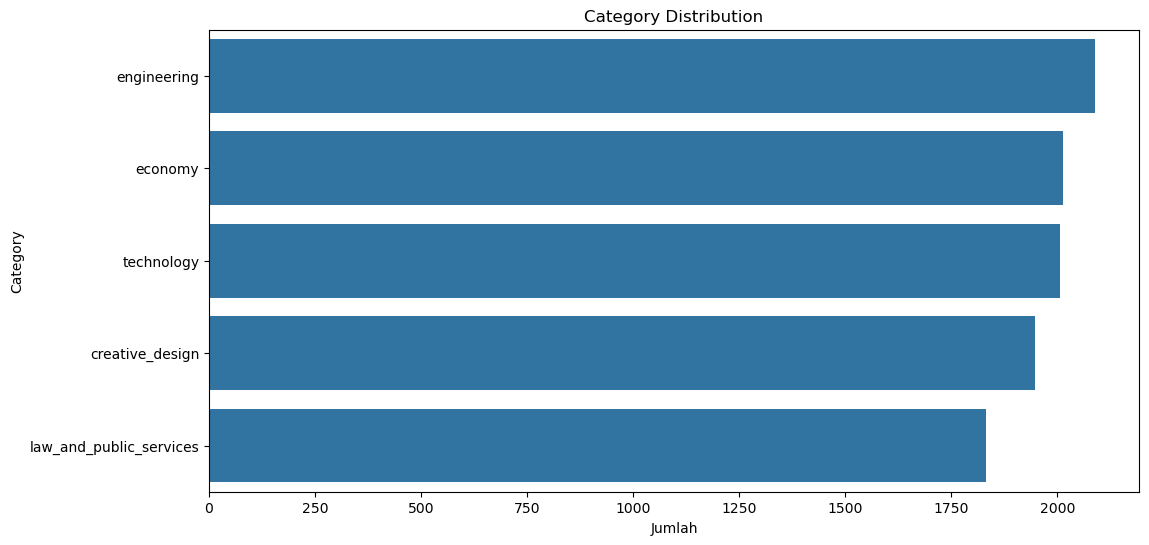

In [48]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=final_df,
    y="category",
    order=final_df["category"].value_counts().index
)

plt.title("Category Distribution")
plt.xlabel("Jumlah")
plt.ylabel("Category")

plt.show()

In [49]:
category_count = final_df["category"].value_counts()

print("Category terbesar:")
print(category_count.max())

print("\nCategory terkecil:")
print(category_count.min())

print("\nRasio imbalance:")
print(round(category_count.max() / category_count.min(), 2))

Category terbesar:
2088

Category terkecil:
1832

Rasio imbalance:
1.14


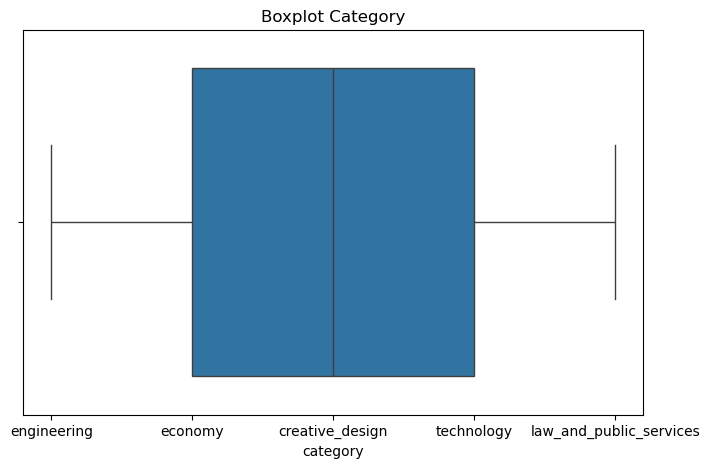

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=final_df["category"]
)

plt.title("Boxplot Category")

plt.show()

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=final_df["match_score"]
)

plt.title("Boxplot Match Score")

plt.show()

KeyError: 'match_score'

<Figure size 800x500 with 0 Axes>

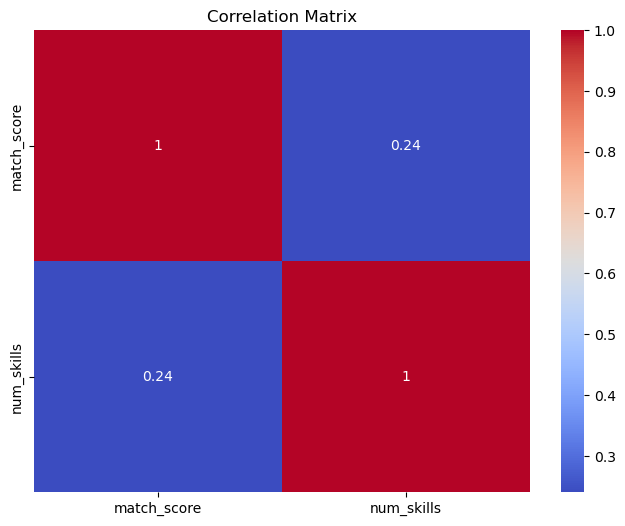

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Matched skills

In [ ]:
# ======================================
# UBAH STRING LIST -> PYTHON LIST
# ======================================

list_columns = [
    'soft_skills_user',
    'required_soft_skills',
    'hard_skills_user',
    'required_hard_skills_user'
]

for col in list_columns:

    final_df[col] = final_df[col].apply(

        lambda x:
        ast.literal_eval(x)
        if isinstance(x, str)
        else x
    )

# ======================================
# MATCHED SKILLS
# ======================================

final_df['matched_skills'] = final_df.apply(

    lambda row:

        list(

            set(
                row['soft_skills_user']
                + row['hard_skills_user']
            )

            &

            set(
                row['required_soft_skills']
                + row['required_hard_skills_user']
            )

        ),

    axis=1
)

# ======================================
# CEK HASIL
# ======================================

final_df.head()

,resume_text,job_role,education,category,education_requirement,soft_skills_user,required_soft_skills,hard_skills_user,required_hard_skills_user,matched_skills
0,education: bachelor's in civil engineering exp...,geotechnical engineer,bachelor's in civil engineering,engineering,bachelor's in civil engineering,"[critical thinking, responsibility, profession...","[analysis, critical thinking, precision]","[technical drawing, structural analysis, build...","[structural analysis, building codes, technica...","[building codes, technical drawing, critical t..."
1,education: bachelor's in marketing experience:...,email marketing specialist,bachelor's in marketing,economy,bachelor's in marketing,"[attention to detail, communication, creativit...","[communication, creativity, attention to detail]","[copywriting, crm, financial analysis, audit p...","[copywriting, crm, campaign management]","[crm, attention to detail, copywriting, creati..."
2,education: bachelor's in robotics engineering ...,robotics engineer,bachelor's in robotics engineering,engineering,bachelor's in robotics engineering,"[problem solving, strategic thinking, quick th...","[creativity, problem solving, strategic thinking]","[microcontrollers, embedded systems, electrica...","[embedded systems, microcontrollers, matlab]","[embedded systems, microcontrollers, strategic..."
3,education: bachelor's in business experience: ...,sales manager,bachelor's in business,economy,bachelor's in business,[business acumen],"[decision making, communication, business acumen]",[crm],[crm],"[crm, business acumen]"
4,education: bachelor's in multimedia experience...,fashion designer,bachelor's in multimedia,creative_design,bachelor's in fashion design|creative design c...,"[strategic planning, critical thinking, proble...","[budget control, teamwork, business acumen]","[rendering, texturing]","[rendering, adobe creative suite]","[teamwork, budget control, rendering]"


### Skill gap

In [ ]:
final_df['skill_gap'] = final_df.apply(

    lambda row: list(

        (
            set(row['required_soft_skills']) |
            set(row['required_hard_skills_user'])
        )

        -

        (
            set(row['soft_skills_user']) |
            set(row['hard_skills_user'])
        )

    ),

    axis=1
)


final_df[
    [
        'job_role',
        'soft_skills_user',
        'required_soft_skills',
        'hard_skills_user',
        'required_hard_skills_user',
        'matched_skills',
        'skill_gap'
    ]
].head()

,job_role,soft_skills_user,required_soft_skills,hard_skills_user,required_hard_skills_user,matched_skills,skill_gap
0,geotechnical engineer,"[critical thinking, responsibility, profession...","[analysis, critical thinking, precision]","[technical drawing, structural analysis, build...","[structural analysis, building codes, technica...","[building codes, technical drawing, critical t...","[analysis, precision]"
1,email marketing specialist,"[attention to detail, communication, creativit...","[communication, creativity, attention to detail]","[copywriting, crm, financial analysis, audit p...","[copywriting, crm, campaign management]","[crm, attention to detail, copywriting, creati...",[campaign management]
2,robotics engineer,"[problem solving, strategic thinking, quick th...","[creativity, problem solving, strategic thinking]","[microcontrollers, embedded systems, electrica...","[embedded systems, microcontrollers, matlab]","[embedded systems, microcontrollers, strategic...","[creativity, matlab]"
3,sales manager,[business acumen],"[decision making, communication, business acumen]",[crm],[crm],"[crm, business acumen]","[decision making, communication]"
4,fashion designer,"[strategic planning, critical thinking, proble...","[budget control, teamwork, business acumen]","[rendering, texturing]","[rendering, adobe creative suite]","[teamwork, budget control, rendering]","[business acumen, adobe creative suite]"


### Match Score

In [ ]:
def calculate_match_score(row):

    # ----------------------------------
    # GABUNG REQUIRED SKILLS
    # ----------------------------------

    required_skills = set(
        row['required_soft_skills']
    ) | set(
        row['required_hard_skills_user']
    )

    # ----------------------------------
    # GABUNG USER SKILLS
    # ----------------------------------

    user_skills = set(
        row['soft_skills_user']
    ) | set(
        row['hard_skills_user']
    )

    # ----------------------------------
    # HITUNG MATCHED SKILLS
    # ----------------------------------

    matched_skills = required_skills & user_skills

    # ----------------------------------
    # SKILL SCORE
    # ----------------------------------

    if len(required_skills) == 0:
        skill_score = 0
    else:
        skill_score = len(matched_skills) / len(required_skills)

    # ----------------------------------
    # EDUCATION SCORE
    # ----------------------------------

    education_list = [
        edu.strip()
        for edu in row['education_requirement'].split('|')
    ]

    education_score = 1 if row['education'] in education_list else 0

    # ----------------------------------
    # FINAL SCORE
    # 80% skills + 20% education
    # ----------------------------------

    final_score = (
        (skill_score * 0.8) +
        (education_score * 0.2)
    )

    return round(final_score, 2)

# ======================================
# APPLY MATCH SCORE
# ======================================

final_df['match_score'] = final_df.apply(
    calculate_match_score,
    axis=1
)

# ======================================
# CEK HASIL
# ======================================

final_df[
    [
        'job_role',
        'education',
        'education_requirement',
        'matched_skills',
        'skill_gap',
        'match_score'
    ]
].head()

,job_role,education,education_requirement,matched_skills,skill_gap,match_score
0,geotechnical engineer,bachelor's in civil engineering,bachelor's in civil engineering,"[building codes, technical drawing, critical t...","[analysis, precision]",0.73
1,email marketing specialist,bachelor's in marketing,bachelor's in marketing,"[crm, attention to detail, copywriting, creati...",[campaign management],0.87
2,robotics engineer,bachelor's in robotics engineering,bachelor's in robotics engineering,"[embedded systems, microcontrollers, strategic...","[creativity, matlab]",0.73
3,sales manager,bachelor's in business,bachelor's in business,"[crm, business acumen]","[decision making, communication]",0.60
4,fashion designer,bachelor's in multimedia,bachelor's in fashion design|creative design c...,"[teamwork, budget control, rendering]","[business acumen, adobe creative suite]",0.48


### Cek tabel akhir dan simpan

In [ ]:
final_df.head()

final_df.to_csv("dataset_with_features.csv", index=False)

### Jawaban Bussines Question

In [ ]:
# =====================================================
# Membuat Hard Skills dan Soft Skills
# =====================================================

import pandas as pd

# Daftar soft skills
soft_skill_keywords = [
    "communication",
    "leadership",
    "teamwork",
    "problem solving",
    "creativity",
    "adaptability",
    "critical thinking",
    "time management",
    "collaboration"
]

# Fungsi split skill
def split_skills(skill_list):

    soft_skills = []
    hard_skills = []

    # memastikan data berupa list
    if isinstance(skill_list, list):

        for skill in skill_list:

            skill_lower = str(skill).lower()

            if skill_lower in soft_skill_keywords:

                soft_skills.append(skill)

            else:

                hard_skills.append(skill)

    return pd.Series([hard_skills, soft_skills])



In [ ]:
df_dataset = pd.read_csv("dataset_with_features.csv")
df_dataset.head()

,resume_text,job_role,education,category,education_requirement,soft_skills_user,required_soft_skills,hard_skills_user,required_hard_skills_user,matched_skills,skill_gap,match_score
0,education: bachelor's in civil engineering exp...,geotechnical engineer,bachelor's in civil engineering,engineering,bachelor's in civil engineering,"['critical thinking', 'responsibility', 'profe...","['analysis', 'critical thinking', 'precision']","['technical drawing', 'structural analysis', '...","['structural analysis', 'building codes', 'tec...","['building codes', 'technical drawing', 'criti...","['analysis', 'precision']",0.73
1,education: bachelor's in marketing experience:...,email marketing specialist,bachelor's in marketing,economy,bachelor's in marketing,"['attention to detail', 'communication', 'crea...","['communication', 'creativity', 'attention to ...","['copywriting', 'crm', 'financial analysis', '...","['copywriting', 'crm', 'campaign management']","['crm', 'attention to detail', 'copywriting', ...",['campaign management'],0.87
2,education: bachelor's in robotics engineering ...,robotics engineer,bachelor's in robotics engineering,engineering,bachelor's in robotics engineering,"['problem solving', 'strategic thinking', 'qui...","['creativity', 'problem solving', 'strategic t...","['microcontrollers', 'embedded systems', 'elec...","['embedded systems', 'microcontrollers', 'matl...","['embedded systems', 'microcontrollers', 'stra...","['creativity', 'matlab']",0.73
3,education: bachelor's in business experience: ...,sales manager,bachelor's in business,economy,bachelor's in business,['business acumen'],"['decision making', 'communication', 'business...",['crm'],['crm'],"['crm', 'business acumen']","['decision making', 'communication']",0.60
4,education: bachelor's in multimedia experience...,fashion designer,bachelor's in multimedia,creative_design,bachelor's in fashion design|creative design c...,"['strategic planning', 'critical thinking', 'p...","['budget control', 'teamwork', 'business acumen']","['rendering', 'texturing']","['rendering', 'adobe creative suite']","['teamwork', 'budget control', 'rendering']","['business acumen', 'adobe creative suite']",0.48



TOP 10 HARD SKILLS
python                  1006
excel                    913
cad                      896
sql                      820
process design           728
legal research           724
matlab                   699
rest api                 688
adobe creative suite     676
graphic design           675
dtype: int64


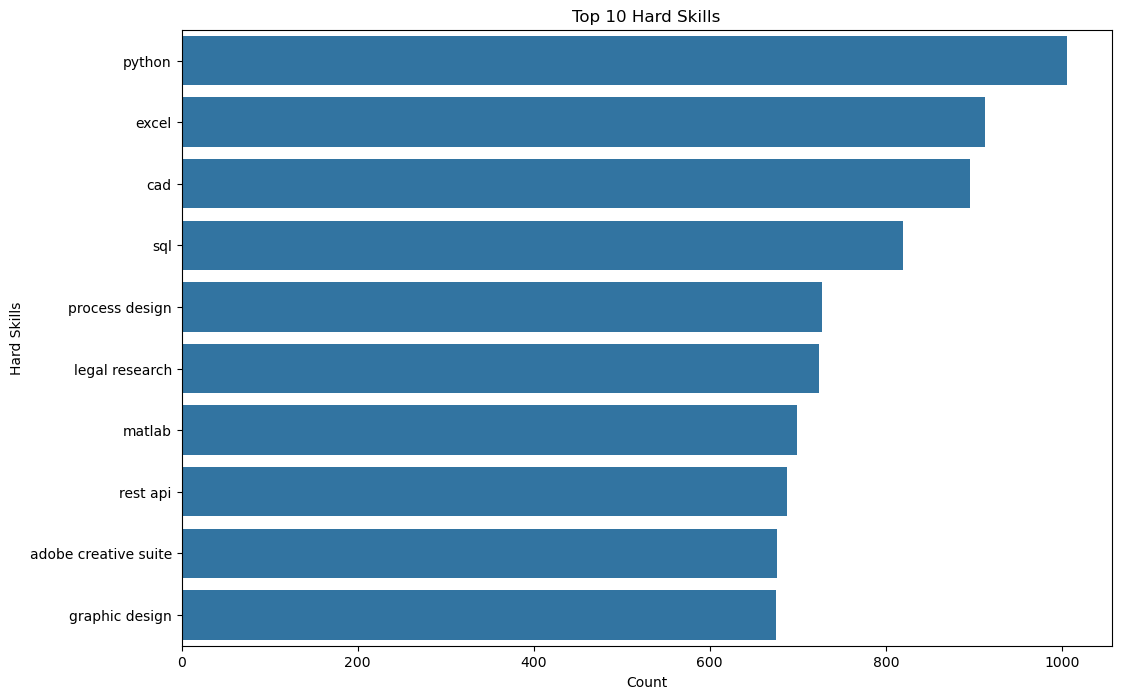

In [ ]:
# =====================================================
# TOP 10 HARD SKILLS
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast

# -----------------------------------------------------
# Convert string list menjadi list asli
# -----------------------------------------------------

df_dataset["hard_skills_user"] = df_dataset[
    "hard_skills_user"
].apply(
    lambda x: ast.literal_eval(x)
    if isinstance(x, str)
    else x
)

# -----------------------------------------------------
# Menggabungkan semua hard skills
# -----------------------------------------------------

all_hard_skills = []

for skills in df_dataset["hard_skills_user"]:

    if isinstance(skills, list):

        all_hard_skills.extend(skills)

# -----------------------------------------------------
# Menghitung jumlah hard skill
# -----------------------------------------------------

skill_counts = pd.Series(
    Counter(all_hard_skills)
).sort_values(
    ascending=False
)

# -----------------------------------------------------
# Menampilkan Top 10 Hard Skills
# -----------------------------------------------------

top_10_hard_skills = skill_counts.head(10)

print("\nTOP 10 HARD SKILLS")
print(top_10_hard_skills)

# -----------------------------------------------------
# Visualisasi Top 10 Hard Skills
# -----------------------------------------------------

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_10_hard_skills.values,
    y=top_10_hard_skills.index
)

plt.title("Top 10 Hard Skills")
plt.xlabel("Count")
plt.ylabel("Hard Skills")

plt.show()


TOP 10 SOFT SKILLS
problem solving        1859
communication          1789
critical thinking      1578
analysis               1529
collaboration          1390
adaptability           1382
teamwork               1355
attention to detail    1347
precision              1314
planning               1295
dtype: int64


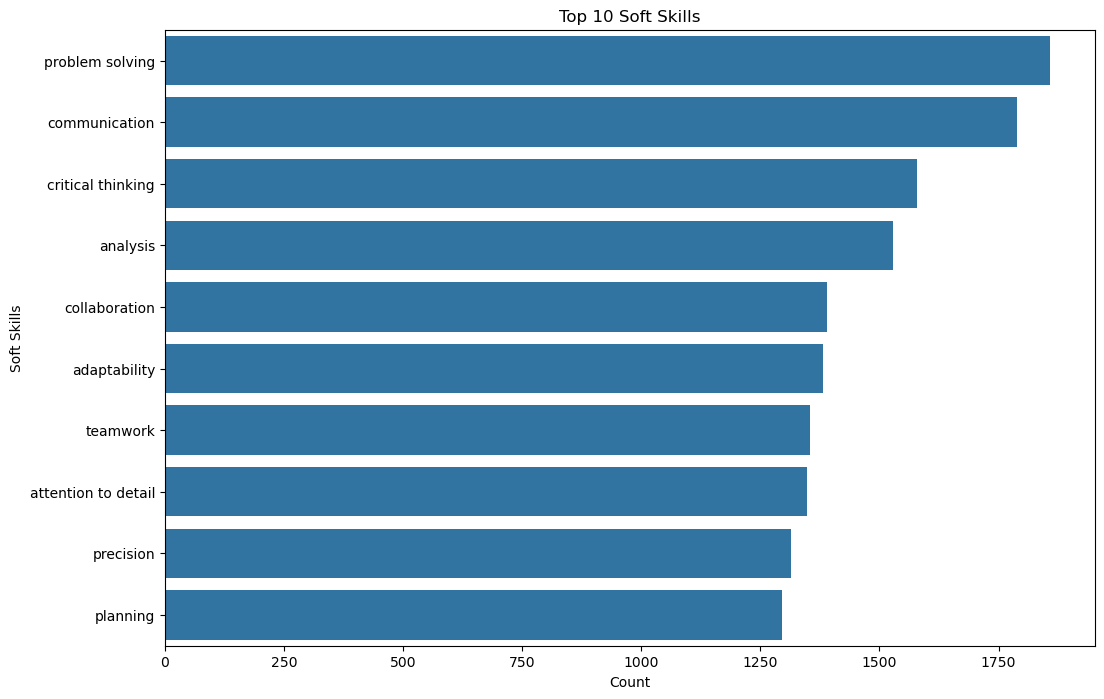

In [ ]:
# =====================================================
# TOP 10 SOFT SKILLS
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast

# -----------------------------------------------------
# Convert string list menjadi list asli
# -----------------------------------------------------

df_dataset["soft_skills_user"] = df_dataset[
    "soft_skills_user"
].apply(
    lambda x: ast.literal_eval(x)
    if isinstance(x, str)
    else x
)

# -----------------------------------------------------
# Menggabungkan semua soft skills
# -----------------------------------------------------

all_soft_skills = []

for skills in df_dataset["soft_skills_user"]:

    if isinstance(skills, list):

        all_soft_skills.extend(skills)

# -----------------------------------------------------
# Menghitung jumlah soft skill
# -----------------------------------------------------

soft_skill_counts = pd.Series(
    Counter(all_soft_skills)
).sort_values(
    ascending=False
)

# -----------------------------------------------------
# Menampilkan Top 10 Soft Skills
# -----------------------------------------------------

top_10_soft_skills = soft_skill_counts.head(10)

print("\nTOP 10 SOFT SKILLS")
print(top_10_soft_skills)

# -----------------------------------------------------
# Visualisasi Top 10 Soft Skills
# -----------------------------------------------------

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_10_soft_skills.values,
    y=top_10_soft_skills.index
)

plt.title("Top 10 Soft Skills")
plt.xlabel("Count")
plt.ylabel("Soft Skills")

plt.show()

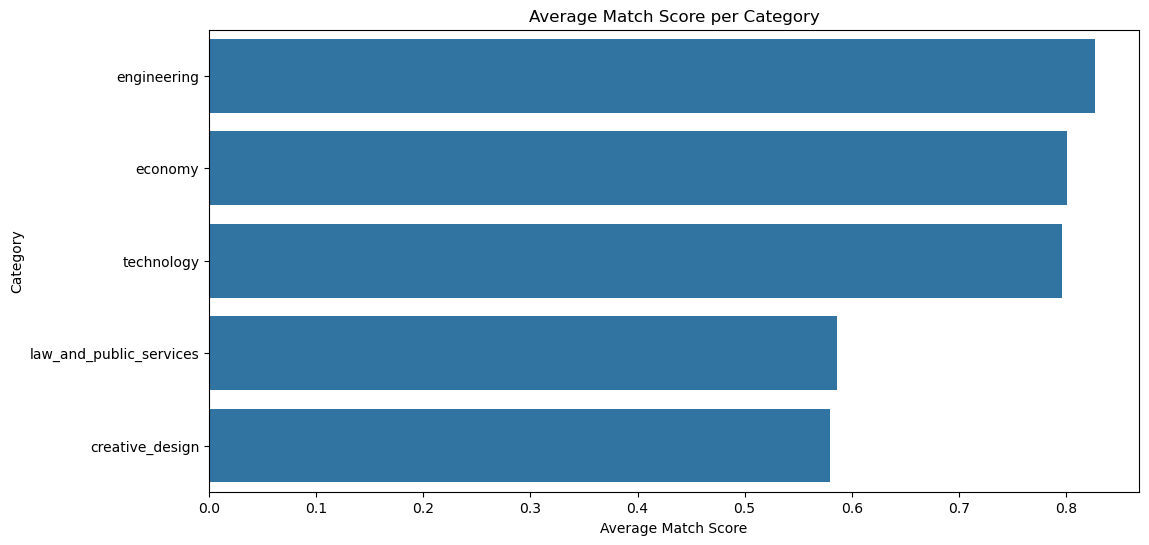

In [ ]:
# Kategori pekerjaan apa yang memiliki tingkat kecocokan (match score) tertinggi?”

avg_match = (
    final_df.groupby('category')['match_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_match.values,
    y=avg_match.index
)

plt.title('Average Match Score per Category')
plt.xlabel('Average Match Score')
plt.ylabel('Category')
plt.show()


TOP 10 REQUIRED HARD SKILLS
excel                   905
graphic design          822
adobe creative suite    804
sql                     779
cad                     754
matlab                  637
legal research          635
process design          628
python                  606
policy knowledge        583
dtype: int64


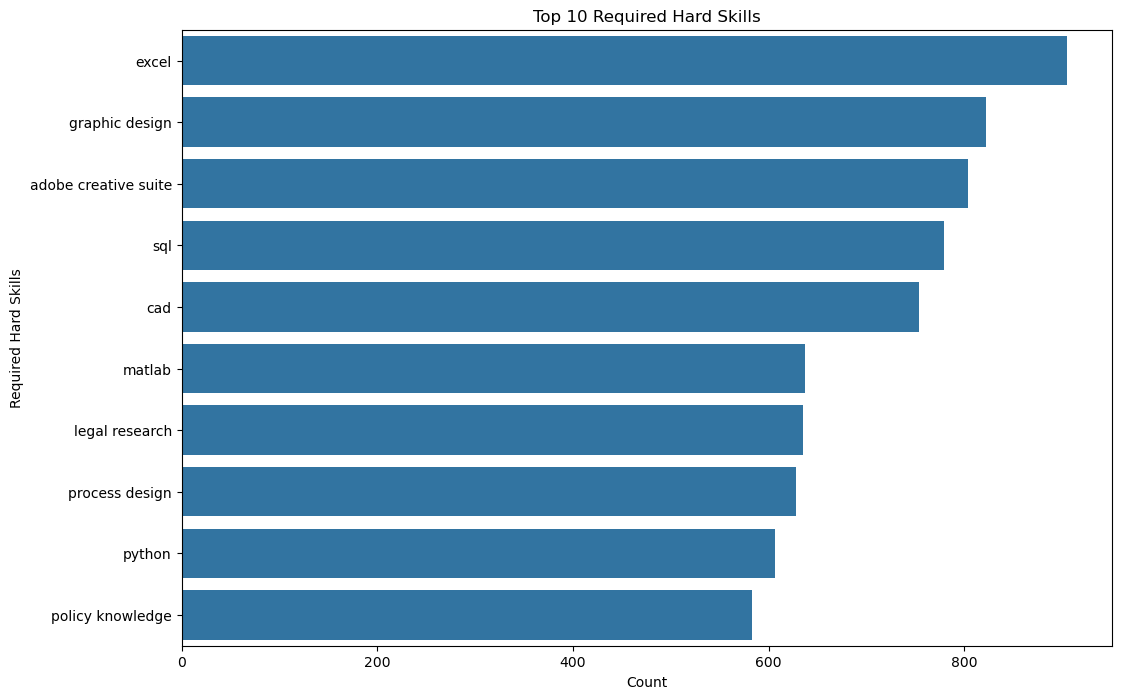

In [ ]:
# =====================================================
# TOP 10 REQUIRED HARD SKILLS
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast

# -----------------------------------------------------
# Convert string list menjadi list asli
# -----------------------------------------------------

df_dataset["required_hard_skills_user"] = df_dataset[
    "required_hard_skills_user"
].apply(
    lambda x: ast.literal_eval(x)
    if isinstance(x, str)
    else x
)

# -----------------------------------------------------
# Menggabungkan semua required hard skills
# -----------------------------------------------------

all_required_hard_skills = []

for skills in df_dataset["required_hard_skills_user"]:

    if isinstance(skills, list):

        all_required_hard_skills.extend(skills)

# -----------------------------------------------------
# Menghitung jumlah required hard skills
# -----------------------------------------------------

required_hard_skill_counts = pd.Series(
    Counter(all_required_hard_skills)
).sort_values(
    ascending=False
)

# -----------------------------------------------------
# Top 10 Required Hard Skills
# -----------------------------------------------------

top_10_required_hard_skills = (
    required_hard_skill_counts.head(10)
)

print("\nTOP 10 REQUIRED HARD SKILLS")
print(top_10_required_hard_skills)

# -----------------------------------------------------
# Visualisasi
# -----------------------------------------------------

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_10_required_hard_skills.values,
    y=top_10_required_hard_skills.index
)

plt.title("Top 10 Required Hard Skills")
plt.xlabel("Count")
plt.ylabel("Required Hard Skills")

plt.show()


TOP 10 REQUIRED SOFT SKILLS
problem solving        2017
communication          1986
critical thinking      1621
analysis               1616
attention to detail    1329
adaptability           1310
collaboration          1301
teamwork               1294
precision              1282
planning               1225
dtype: int64


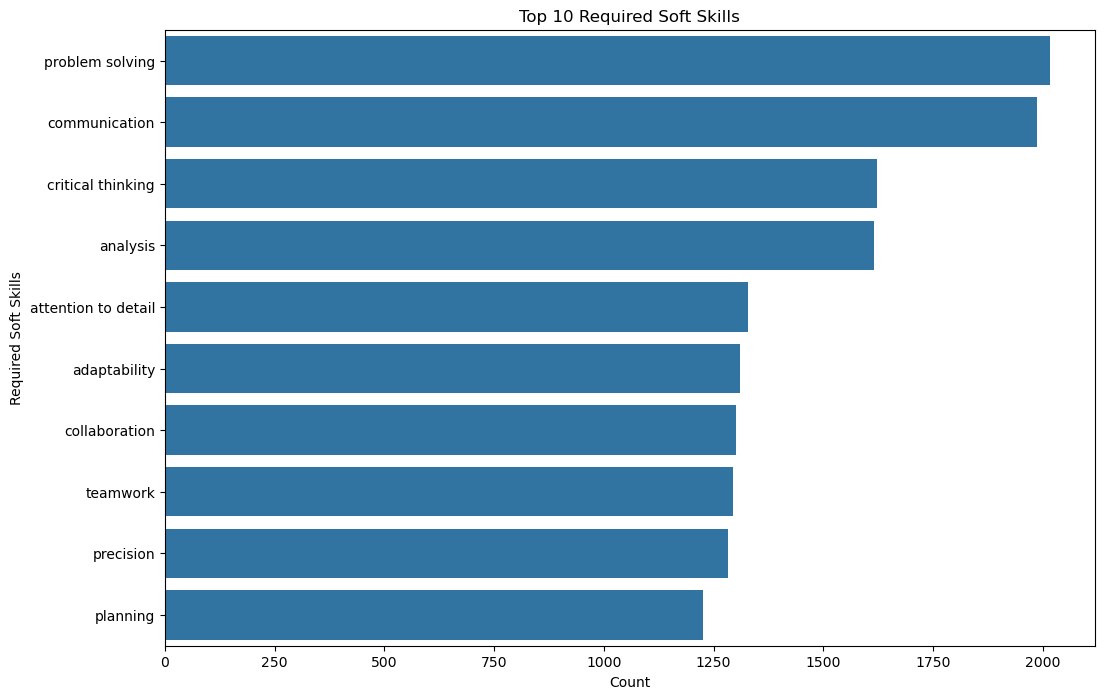

In [ ]:
# =====================================================
# TOP 10 REQUIRED SOFT SKILLS
# =====================================================



# -----------------------------------------------------
# Convert string list menjadi list asli
# -----------------------------------------------------

df_dataset["required_soft_skills"] = df_dataset[
    "required_soft_skills"
].apply(
    lambda x: ast.literal_eval(x)
    if isinstance(x, str)
    else x
)

# -----------------------------------------------------
# Menggabungkan semua required soft skills
# -----------------------------------------------------

all_required_soft_skills = []

for skills in df_dataset["required_soft_skills"]:

    if isinstance(skills, list):

        all_required_soft_skills.extend(skills)

# -----------------------------------------------------
# Menghitung jumlah required soft skills
# -----------------------------------------------------

required_soft_skill_counts = pd.Series(
    Counter(all_required_soft_skills)
).sort_values(
    ascending=False
)

# -----------------------------------------------------
# Top 10 Required Soft Skills
# -----------------------------------------------------

top_10_required_soft_skills = (
    required_soft_skill_counts.head(10)
)

print("\nTOP 10 REQUIRED SOFT SKILLS")
print(top_10_required_soft_skills)

# -----------------------------------------------------
# Visualisasi
# -----------------------------------------------------

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_10_required_soft_skills.values,
    y=top_10_required_soft_skills.index
)

plt.title("Top 10 Required Soft Skills")
plt.xlabel("Count")
plt.ylabel("Required Soft Skills")

plt.show()

In [52]:
# ==========================================
# BUSINESS QUESTION 1
# Apa hard skill yang paling sering dimiliki pengguna?
# ==========================================

from collections import Counter

all_hard_skills = [
    skill
    for skills in final_df["hard_skills"]
    for skill in skills
]

hard_skill_counts = Counter(all_hard_skills)

top_hard_skills = pd.DataFrame(
    hard_skill_counts.items(),
    columns=["Hard Skill", "Jumlah"]
).sort_values(by="Jumlah", ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_hard_skills,
    x="Jumlah",
    y="Hard Skill"
)

plt.title("Top 10 Hard Skill yang Dimiliki Pengguna")
plt.xlabel("Jumlah")
plt.ylabel("Hard Skill")

plt.tight_layout()
plt.show()

KeyError: 'hard_skills'